In [1]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np, pandas as pd
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
import json
from pathlib import Path

def split_xy(df, target):
    y = df[target]
    X = df.drop(columns=[target])
    return X, y

class MissingValueHandler(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = X.copy()
        self.int_cols_ = X.select_dtypes(include=[np.integer]).columns.tolist()
        self.float_cols_ = X.select_dtypes(include=[np.floating]).columns.tolist()
        self.cat_cols_ = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
        self.medians_ = X[self.int_cols_].median(numeric_only=True)
        self.means_ = X[self.float_cols_].mean(numeric_only=True)
        return self
    def transform(self, X):
        X = X.copy()
        if self.int_cols_:
            X[self.int_cols_] = X[self.int_cols_].fillna(self.medians_)
        if self.float_cols_:
            X[self.float_cols_] = X[self.float_cols_].fillna(self.means_)
        if self.cat_cols_:
            X[self.cat_cols_] = X[self.cat_cols_].fillna("(NA)").astype("string")
        return X

def build_two_stage_preprocessor():
    stage1 = MissingValueHandler()
    enc_scale = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), make_column_selector(dtype_include=[np.number])),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True),
                    make_column_selector(dtype_include=["object","string","category"])),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )
    return Pipeline([("stage1_missing", stage1), ("stage2_encode_scale", enc_scale)])

def make_folds(y, n_splits=5, seed=42, out=None, name="dataset"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = [{"train_idx": tr.tolist(), "valid_idx": va.tolist()} for tr,va in skf.split(np.zeros(len(y)), y)]
    if out:
        Path(out).mkdir(parents=True, exist_ok=True)
        Path(out, f"{name}_skf{n_splits}.json").write_text(json.dumps(folds))
    return folds



In [19]:
!chmod +x download_dataset.sh
!bash download_dataset.sh

== UCI via ucimlrepo: Car (id=19) & Covertype (id=31) ==
✓ car: (1728, 7)
✓ covertype: (581012, 55)
== UCI direct ZIP: APS Failure (id=421) ==
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 53.9M    0 53.9M    0     0  11.8M      0 --:--:--  0:00:04 --:--:-- 13.2M
✓ APS: raw/aps_training.csv + raw/aps_test.csv
== OpenML: Jannis (id=41168), retrying up to 5x ==
Traceback (most recent call last):
  File "<stdin>", line 6, in <module>
  File "/usr/local/lib/python3.12/dist-packages/openml/datasets/dataset.py", line 820, in get_data
    data, categorical, attribute_names = self._load_data()
                                         ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openml/datasets/dataset.py", line 607, in _load_data
    self._download_data()
  File "/usr/local/lib/python3.12/dist-packages/openml/datasets/dataset.py", line 365, in _download_data


In [22]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data\raw")
AVAILABLE = {
    "car": {"file": "car.csv", "target": "class"},
    "aps": {"file": "aps_training.csv", "target": "class", "na_values": ["na"]},
    "covertype": {"file": "covertype.csv", "target": "Cover_Type"},
    "jannis": {"file": "jannis.csv", "target": "__target__"},
}

def _exists(name):
    return (DATA_DIR / AVAILABLE[name]["file"]).exists()

print("Available files:")
for k in AVAILABLE:
    print(f" - {k:10s} -> {AVAILABLE[k]['file']}  {'✓' if _exists(k) else '✗'}")

Available files:
 - car        -> car.csv  ✓
 - aps        -> aps_training.csv  ✓
 - covertype  -> covertype.csv  ✓
 - jannis     -> jannis.csv  ✓


In [9]:
DATASET = "car"

In [10]:
from IPython.display import display
import pandas as pd

name = DATASET
info = AVAILABLE[name]
path = (DATA_DIR / info["file"])
read_kwargs = {}
print(info)
if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]

df = pd.read_csv(path, **read_kwargs)
print(f"Loaded: {name} -> {path.name}")
print("Shape:", df.shape)
print("Memory MB (approx):", round(df.memory_usage(index=True, deep=True).sum()/1e6, 2))
print("Columns sample:", list(df.columns)[:12], "..." if df.shape[1] > 12 else "")
display(df.head())

{'file': 'car.csv', 'target': 'class'}
Loaded: car -> car.csv
Shape: (1728, 7)
Memory MB (approx): 0.63
Columns sample: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'] 


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [11]:
DATASET = 'aps'
# Load selected dataset
from IPython.display import display
import pandas as pd

name = DATASET
info = AVAILABLE[name]
path = (DATA_DIR / info["file"])
read_kwargs = {}
print(info)
if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]

df = pd.read_csv(path, **read_kwargs, skiprows = 20)
print(f"Loaded: {name} -> {path.name}")
print("Shape:", df.shape)
print("Memory MB (approx):", round(df.memory_usage(index=True, deep=True).sum()/1e6, 2))
print("Columns sample:", list(df.columns)[:12], "..." if df.shape[1] > 12 else "")
display(df.head())

{'file': 'aps_training.csv', 'target': 'class', 'na_values': ['na']}
Loaded: aps -> aps_training.csv
Shape: (60000, 171)
Memory MB (approx): 84.72
Columns sample: ['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004'] ...


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [12]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import numpy as np

target_col = info["target"]
X, y = split_xy(df, target_col)

# Convert target variable 'y' from string labels to numerical labels
y = y.map({'neg': 0, 'pos': 1})

pre = build_two_stage_preprocessor()

n_classes = y.nunique()
if n_classes > 2:
    objective = "multi:softprob"
    eval_metric = "mlogloss"
    extra = {"num_class": int(n_classes)}
else:
    objective = "binary:logistic"
    eval_metric = "logloss"
    extra = {}

xgb_params = dict(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    objective=objective,
    eval_metric=eval_metric,
    random_state=42,
    tree_method="hist",
    **extra
)

use_gpu = False
try:
    # Prefer modern API
    clf = XGBClassifier(**xgb_params, device="cuda")
    use_gpu = True
except TypeError:
    # Older XGB: use gpu_hist if available
    clf = XGBClassifier(**{**xgb_params, "tree_method": "gpu_hist"})
    use_gpu = True
except Exception:
    # Truly CPU-only fallback
    clf = XGBClassifier(**xgb_params)

pipe = Pipeline([("pre", pre), ("clf", clf)])

print(f"XGBoost device: {'GPU' if use_gpu else 'CPU'}")

folds = make_folds(y, n_splits=4, seed=42, out="data/splits", name=name)

idx = X.sample(min(5000, len(X)), random_state=0).index
_ = pipe.fit(X.loc[idx], y.loc[idx])
print("Pipeline smoke-fit OK.")

XGBoost device: GPU
Pipeline smoke-fit OK.


In [13]:
from sklearn.metrics import accuracy_score, f1_score, log_loss
import numpy as np

scores = []
for i, f in enumerate(folds, 1):
    tr, va = f["train_idx"], f["valid_idx"]
    pipe.fit(X.iloc[tr], y.iloc[tr])
    proba = pipe.predict_proba(X.iloc[va])
    pred  = proba.argmax(1) if proba.shape[1] > 1 else (proba[:,0] >= 0.5).astype(int)
    yv = y.iloc[va]
    acc = accuracy_score(yv, pred)
    f1m = f1_score(yv, pred, average="macro")
    ll  = log_loss(yv, proba, labels=np.unique(y))
    scores.append({"fold": i, "accuracy": acc, "f1_macro": f1m, "logloss": ll})
scores

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:729: UserWarning: [18:47:26] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[{'fold': 1,
  'accuracy': 0.9948,
  'f1_macro': 0.9138971475670425,
  'logloss': 0.01659059365098006},
 {'fold': 2,
  'accuracy': 0.9944,
  'f1_macro': 0.9068752385398156,
  'logloss': 0.017576572796669705},
 {'fold': 3,
  'accuracy': 0.994,
  'f1_macro': 0.8993580084634696,
  'logloss': 0.019649768869946686},
 {'fold': 4,
  'accuracy': 0.9936666666666667,
  'f1_macro': 0.893996678562595,
  'logloss': 0.019511864235226436}]

In [ ]:
'''
from joblib import dump
pipe.fit(X, y)
Path("models").mkdir(exist_ok=True)
dump(pipe, f"models/{name}_xgb_pipeline.joblib")
print("Saved:", f"models/{name}_xgb_pipeline.joblib")
'''

'\nfrom joblib import dump\npipe.fit(X, y)\nPath("models").mkdir(exist_ok=True)\ndump(pipe, f"models/{name}_xgb_pipeline.joblib")\nprint("Saved:", f"models/{name}_xgb_pipeline.joblib")\n'

In [15]:
!pip install scikit-optimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from scipy.stats import randint
from skopt.space import Categorical, Integer
from sklearn.ensemble import RandomForestClassifier

# Hyperparameters for a Random Forest
rf_param_unif = {
    "clf__n_estimators": [50, 100, 150, 200],
    "clf__max_depth": [5, 10],
    "clf__min_samples_split": [2, 5],
    "clf__max_features": ["sqrt", "log2"],
}

rf_param_bayes = {
    "clf__n_estimators": Categorical([50, 100, 150, 200]),
    "clf__max_depth": Categorical([5, 10]),
    "clf__min_samples_split": Categorical([2, 5]),
    "clf__max_features": Categorical(["sqrt", "log2"]),
}


def search_rf(X, y, method="random", n_iter=10, cv=2, seed=42):
    pre = build_two_stage_preprocessor()
    clf = RandomForestClassifier(random_state=seed, n_jobs=-1)
    pipe = Pipeline([("pre", pre), ("clf", clf)])

    if method == "random":
        search = RandomizedSearchCV(
            pipe, rf_param_unif, n_iter=n_iter, cv=cv,
            scoring="accuracy", random_state=seed, n_jobs=-1, verbose=1
        )
    elif method == "bayes":
        search = BayesSearchCV(
            pipe, rf_param_bayes, n_iter=n_iter, cv=cv,
            scoring="accuracy", random_state=seed, n_jobs=-1, verbose=1
        )
    else:
        raise ValueError("method must be 'random' or 'bayes'")

    search.fit(X, y)
    return search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.9 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import PredefinedSplit

DATASET = "car"
info = AVAILABLE[DATASET]
path = DATA_DIR / info["file"]
read_kwargs = {}
if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]

df = pd.read_csv(path, **read_kwargs)
X, y = split_xy(df, info["target"])
folds = make_folds(y, n_splits=2, seed=42, out="data/splits", name=DATASET)

test_fold = np.full(len(y), -1)

for i, f in enumerate(folds):
    test_fold[f["valid_idx"]] = i
ps = PredefinedSplit(test_fold)

# ---- RandomizedSearchCV ----
print(f"Running RandomizedSearchCV for {DATASET}")
rs_result = search_rf(X, y, method="random", n_iter=10, cv=ps)
print("Best params (RandomizedSearchCV):", rs_result.best_params_)
print("Best score:", rs_result.best_score_)

# ---- BayesSearchCV ----
print(f"\nRunning BayesSearchCV for {DATASET}")
bs_result = search_rf(X, y, method="bayes", n_iter=10, cv=ps)
print("Best params (BayesSearchCV):", bs_result.best_params_)
print("Best score:", bs_result.best_score_)

Running RandomizedSearchCV for car
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best params (RandomizedSearchCV): {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__max_features': 'log2', 'clf__max_depth': 15}
Best score: 0.9537037037037037

Running BayesSearchCV for car
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best params (BayesSearchCV): OrderedDict({'clf__max_depth': 15, 'clf__max_features': 'log2', 'clf__min_samples_

In [ ]:
DATASET = "covertype"
info = AVAILABLE[DATASET]
path = DATA_DIR / info["file"]
read_kwargs = {}
if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]

df = pd.read_csv(path, **read_kwargs)
X, y = split_xy(df, info["target"])
folds = make_folds(y, n_splits=2, seed=42, out="data/splits", name=DATASET)

test_fold = np.full(len(y), -1)

for i, f in enumerate(folds):
    test_fold[f["valid_idx"]] = i
ps = PredefinedSplit(test_fold)

# ---- RandomizedSearchCV ----
print(f"Running RandomizedSearchCV for {DATASET}")
rs_result = search_rf(X, y, method="random", n_iter=8, cv=ps)
print("Best params (RandomizedSearchCV):", rs_result.best_params_)
print("Best score:", rs_result.best_score_)

# ---- BayesSearchCV ----
print(f"\nRunning BayesSearchCV for {DATASET}")
bs_result = search_rf(X, y, method="bayes", n_iter=8, cv=ps)
print("Best params (BayesSearchCV):", bs_result.best_params_)
print("Best score:", bs_result.best_score_)

Running RandomizedSearchCV for covertype
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best params (RandomizedSearchCV): {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
Best score: 0.751881200388288

Running BayesSearchCV for covertype
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best params (BayesSearchCV): OrderedDict({'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200})
Best score: 0.7520550350078827


In [ ]:
DATASET = "aps"
info = AVAILABLE[DATASET]
path = DATA_DIR / info["file"]
read_kwargs = {}
if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]

df = pd.read_csv(path, **read_kwargs, skiprows = 20)
X, y = split_xy(df, info["target"])
folds = make_folds(y, n_splits=2, seed=42, out="data/splits", name=DATASET)

test_fold = np.full(len(y), -1)

for i, f in enumerate(folds):
    test_fold[f["valid_idx"]] = i
ps = PredefinedSplit(test_fold)

# ---- RandomizedSearchCV ----
print(f"Running RandomizedSearchCV for {DATASET}")
rs_result = search_rf(X, y, method="random", n_iter=8, cv=ps)
print("Best params (RandomizedSearchCV):", rs_result.best_params_)
print("Best score:", rs_result.best_score_)

# ---- BayesSearchCV ----
print(f"\nRunning BayesSearchCV for {DATASET}")
bs_result = search_rf(X, y, method="bayes", n_iter=8, cv=ps)
print("Best params (BayesSearchCV):", bs_result.best_params_)
print("Best score:", bs_result.best_score_)

Running RandomizedSearchCV for aps
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best params (RandomizedSearchCV): {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__max_features': 'log2', 'clf__max_depth': 10}
Best score: 0.99205

Running BayesSearchCV for aps
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best params (BayesSearchCV): OrderedDict({'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200})
Best score: 0.9921833333333334


In [ ]:
DATASET = "jannis"
info = AVAILABLE[DATASET]
path = DATA_DIR / info["file"]
read_kwargs = {}
if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]

df = pd.read_csv(path, **read_kwargs)
X, y = split_xy(df, info["target"])
folds = make_folds(y, n_splits=2, seed=42, out="data/splits", name=DATASET)

test_fold = np.full(len(y), -1)

for i, f in enumerate(folds):
    test_fold[f["valid_idx"]] = i
ps = PredefinedSplit(test_fold)

# ---- RandomizedSearchCV ----
print(f"Running RandomizedSearchCV for {DATASET}")
rs_result = search_rf(X, y, method="random", n_iter=8, cv=ps)
print("Best params (RandomizedSearchCV):", rs_result.best_params_)
print("Best score:", rs_result.best_score_)

# ---- BayesSearchCV ----
print(f"\nRunning BayesSearchCV for {DATASET}")
bs_result = search_rf(X, y, method="bayes", n_iter=8, cv=ps)
print("Best params (BayesSearchCV):", bs_result.best_params_)
print("Best score:", bs_result.best_score_)

Running RandomizedSearchCV for jannis
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best params (RandomizedSearchCV): {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
Best score: 0.679791739694187

Running BayesSearchCV for jannis
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best params (BayesSearchCV): OrderedDict({'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 150})
Best score: 0.6799589378120376


In [ ]:
# Convergence for RF and car dataset (due to CPU limitations)

DATASET = "car"
info = AVAILABLE[DATASET]
path = DATA_DIR / info["file"]
read_kwargs = {}
if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]

df = pd.read_csv(path, **read_kwargs)
X, y = split_xy(df, info["target"])
folds = make_folds(y, n_splits=2, seed=42, out="data/splits", name=DATASET)

test_fold = np.full(len(y), -1)

for i, f in enumerate(folds):
    test_fold[f["valid_idx"]] = i
ps = PredefinedSplit(test_fold)

rs = np.empty(10)
bs = np.empty(10)

# Hyperparameters for a Random Forest while testing stability
rf_param_unif = {
    "clf__n_estimators": [20, 50, 100, 150, 200, 250, 300],
    "clf__max_depth": [5, 10, 15, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__max_features": ["sqrt", "log2", None]
}

rf_param_bayes = {
    "clf__n_estimators": [20, 50, 100, 150, 200, 250, 300],
    "clf__max_depth": [5, 10, 15, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__max_features": ["sqrt", "log2", None]
}

for i in range(1, 10):

  print(f"Running RandomizedSearchCV for {DATASET}")
  rs_result = search_rf(X, y, method="random", n_iter=i, cv=ps)
  rs[i] = rs_result.best_score_

  print(f"\nRunning BayesSearchCV for {DATASET}")
  bs_result = search_rf(X, y, method="bayes", n_iter=i, cv=ps)
  bs[i] = bs_result.best_score_

Running RandomizedSearchCV for car
Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running BayesSearchCV for car
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Running RandomizedSearchCV for car
Fitting 2 folds for each of 2 candidates, totalling 4 fits

Running BayesSearchCV for car
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Running RandomizedSearchCV for car
Fitting 2 folds for each of 3 candidates, totalling 6 fits

Running BayesSearchCV for car
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Running RandomizedSearchCV for car
Fitting 2 folds for each of 4 candidates, totalling 8 fits

Running BayesSearchCV for car
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 

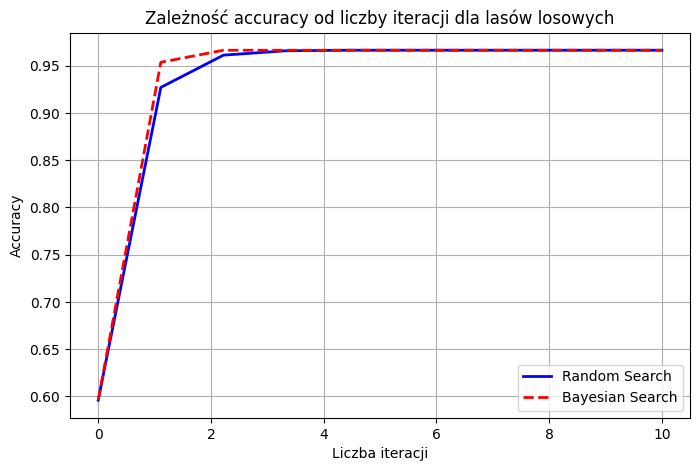

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, 10, 10), rs, label='Random Search', color='blue', linestyle='-', linewidth=2)
plt.plot(np.linspace(0, 10, 10), bs, label='Bayesian Search', color='red', linestyle='--', linewidth=2)

plt.title('Zależność accuracy od liczby iteracji dla lasów losowych')
plt.xlabel('Liczba iteracji')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Testing Goodness of Fit using Kolmogorov-Smirnov Test
from scipy.stats import kstest

DATASET = "car"
info = AVAILABLE[DATASET]
path = DATA_DIR / info["file"]
read_kwargs = {}
if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]

df = pd.read_csv(path, **read_kwargs)
X, y = split_xy(df, info["target"])
folds = make_folds(y, n_splits=2, seed=42, out="data/splits", name=DATASET)

test_fold = np.full(len(y), -1)

for i, f in enumerate(folds):
    test_fold[f["valid_idx"]] = i
ps = PredefinedSplit(test_fold)

rs_test = np.empty(10)
bs_test = np.empty(10)

# Hyperparameters for a Random Forest while testing Goodness of Fit
rf_param_unif = {
    "clf__n_estimators": [20, 50, 100, 150, 200, 250, 300],
    "clf__max_depth": [5, 10, 15, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__max_features": ["sqrt", "log2", None]
}

rf_param_bayes = {
    "clf__n_estimators": [20, 50, 100, 150, 200, 250, 300],
    "clf__max_depth": [5, 10, 15, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__max_features": ["sqrt", "log2", None]
}

def search_rf(X, y, method="random", n_iter=10, cv=2, seed=42):
    pre = build_two_stage_preprocessor()
    clf = RandomForestClassifier(random_state=seed, n_jobs=-1)
    pipe = Pipeline([("pre", pre), ("clf", clf)])

    if method == "random":
        search = RandomizedSearchCV(
            pipe, rf_param_unif, n_iter=n_iter, cv=cv,
            scoring="accuracy", random_state=seed, n_jobs=-1, verbose=1
        )
    elif method == "bayes":
        search = BayesSearchCV(
            pipe, rf_param_bayes, n_iter=n_iter, cv=cv,
            scoring="accuracy", random_state=seed, n_jobs=-1, verbose=1
        )
    else:
        raise ValueError("method must be 'random' or 'bayes'")

    search.fit(X, y)
    return search

for i in range(1, 10):

  rs_result = search_rf(X, y, method="random", n_iter=4, cv=2, seed = i)
  rs_test[i] = rs_result.best_score_

  bs_result = search_rf(X, y, method="bayes", n_iter=4, cv=2, seed = i)
  bs_test[i] = bs_result.best_score_

  del rs_result, bs_result

kstest(rs_test, bs_test)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fi

KstestResult(statistic=np.float64(0.2), pvalue=np.float64(0.9944575548290717), statistic_location=np.float64(0.6967592592592593), statistic_sign=np.int8(-1))

In [ ]:
rs_test, bs_test

(array([0.59595013, 0.71643519, 0.69907407, 0.7037037 , 0.69791667,
        0.70196759, 0.68402778, 0.70833333, 0.69328704, 0.70023148]),
 array([0.59595013, 0.72569444, 0.67766204, 0.70717593, 0.68923611,
        0.70601852, 0.69675926, 0.70081019, 0.69618056, 0.70081019]))

In [23]:
# Tunability (cars)

from sklearn.model_selection import train_test_split

# RandomSearch and Bayes (the same)

pre = build_two_stage_preprocessor()
clf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200, min_samples_split=2, max_features='log2', max_depth=15)
pipe = Pipeline([("pre", pre), ("clf", clf)])

for i in AVAILABLE:
  DATASET = i
  info = AVAILABLE[DATASET]
  path = DATA_DIR / info["file"]
  read_kwargs = {}
  if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]
  if i == 'aps':
    df = pd.read_csv(path, **read_kwargs, skiprows = 20)
  else:
    df = pd.read_csv(path, **read_kwargs)
  X, y = split_xy(df, info["target"])
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"Accuracy dla zbioru {i}: {accuracy}.")


Accuracy dla zbioru car: 0.9595375722543352.
Accuracy dla zbioru aps: 0.9930555555555556.
Accuracy dla zbioru covertype: 0.8134064622728108.
Accuracy dla zbioru jannis: 0.6918789808917197.


In [24]:
# Tunability (covertype)

# RandomSearch

pre = build_two_stage_preprocessor()
clf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=100, min_samples_split=2, max_features='sqrt', max_depth=10)
pipe = Pipeline([("pre", pre), ("clf", clf)])

for i in AVAILABLE:
  DATASET = i
  info = AVAILABLE[DATASET]
  path = DATA_DIR / info["file"]
  read_kwargs = {}
  if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]
  if i == 'aps':
    df = pd.read_csv(path, **read_kwargs, skiprows = 20)
  else:
    df = pd.read_csv(path, **read_kwargs)
  X, y = split_xy(df, info["target"])
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"Accuracy dla zbioru {i}: {accuracy}.")

# Bayes

pre = build_two_stage_preprocessor()
clf_b = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200, min_samples_split=5, max_features='sqrt', max_depth=10)
pipe = Pipeline([("pre", pre), ("clf", clf_b)])

for i in AVAILABLE:
  DATASET = i
  info = AVAILABLE[DATASET]
  path = DATA_DIR / info["file"]
  read_kwargs = {}
  if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]
  if i == 'aps':
    df = pd.read_csv(path, **read_kwargs, skiprows = 20)
  else:
    df = pd.read_csv(path, **read_kwargs)
  X, y = split_xy(df, info["target"])
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"Accuracy dla zbioru {i}: {accuracy}.")

Accuracy dla zbioru car: 0.9460500963391136.
Accuracy dla zbioru aps: 0.9927777777777778.
Accuracy dla zbioru covertype: 0.7514170644391408.
Accuracy dla zbioru jannis: 0.6771496815286624.
Accuracy dla zbioru car: 0.9402697495183044.
Accuracy dla zbioru aps: 0.9931666666666666.
Accuracy dla zbioru covertype: 0.7483534514411603.
Accuracy dla zbioru jannis: 0.677906050955414.


In [25]:
# Tunability (aps)

# RandomSearch

pre = build_two_stage_preprocessor()
clf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=100, min_samples_split=2, max_features='log2', max_depth=10)
pipe = Pipeline([("pre", pre), ("clf", clf)])

for i in AVAILABLE:
  DATASET = i
  info = AVAILABLE[DATASET]
  path = DATA_DIR / info["file"]
  read_kwargs = {}
  if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]
  if i == 'aps':
    df = pd.read_csv(path, **read_kwargs, skiprows = 20)
  else:
    df = pd.read_csv(path, **read_kwargs)
  X, y = split_xy(df, info["target"])
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"RandomSearch - accuracy dla zbioru {i}: {accuracy}.")

# Bayes

pre = build_two_stage_preprocessor()
clf_b = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200, min_samples_split=5, max_features='sqrt', max_depth=10)
pipe = Pipeline([("pre", pre), ("clf", clf_b)])

for i in AVAILABLE:
  DATASET = i
  info = AVAILABLE[DATASET]
  path = DATA_DIR / info["file"]
  read_kwargs = {}
  if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]
  if i == 'aps':
    df = pd.read_csv(path, **read_kwargs, skiprows = 20)
  else:
    df = pd.read_csv(path, **read_kwargs)
  X, y = split_xy(df, info["target"])
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"BayesSearch - accuracy dla zbioru {i}: {accuracy}.")

RandomSearch - accuracy dla zbioru car: 0.9460500963391136.
RandomSearch - accuracy dla zbioru aps: 0.9931111111111111.
RandomSearch - accuracy dla zbioru covertype: 0.7409812740958326.
RandomSearch - accuracy dla zbioru jannis: 0.6714968152866242.
BayesSearch - accuracy dla zbioru car: 0.9402697495183044.
BayesSearch - accuracy dla zbioru aps: 0.9931666666666666.
BayesSearch - accuracy dla zbioru covertype: 0.7483534514411603.
BayesSearch - accuracy dla zbioru jannis: 0.677906050955414.


In [26]:
# Tunability (jannis)

# RandomSearch

pre = build_two_stage_preprocessor()
clf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=100, min_samples_split=2, max_features='sqrt', max_depth=10)
pipe = Pipeline([("pre", pre), ("clf", clf)])

for i in AVAILABLE:
  DATASET = i
  info = AVAILABLE[DATASET]
  path = DATA_DIR / info["file"]
  read_kwargs = {}
  if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]
  if i == 'aps':
    df = pd.read_csv(path, **read_kwargs, skiprows = 20)
  else:
    df = pd.read_csv(path, **read_kwargs)
  X, y = split_xy(df, info["target"])
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"RandomSearch - accuracy dla zbioru {i}: {accuracy}.")

# Bayes

pre = build_two_stage_preprocessor()
clf_b = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=150, min_samples_split=5, max_features='sqrt', max_depth=10)
pipe = Pipeline([("pre", pre), ("clf", clf_b)])

for i in AVAILABLE:
  DATASET = i
  info = AVAILABLE[DATASET]
  path = DATA_DIR / info["file"]
  read_kwargs = {}
  if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]
  if i == 'aps':
    df = pd.read_csv(path, **read_kwargs, skiprows = 20)
  else:
    df = pd.read_csv(path, **read_kwargs)
  X, y = split_xy(df, info["target"])
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"BayesSearch - accuracy dla zbioru {i}: {accuracy}.")

RandomSearch - accuracy dla zbioru car: 0.9460500963391136.
RandomSearch - accuracy dla zbioru aps: 0.9927777777777778.
RandomSearch - accuracy dla zbioru covertype: 0.7514170644391408.
RandomSearch - accuracy dla zbioru jannis: 0.6771496815286624.
BayesSearch - accuracy dla zbioru car: 0.9441233140655106.
BayesSearch - accuracy dla zbioru aps: 0.9931111111111111.
BayesSearch - accuracy dla zbioru covertype: 0.748301817514228.
BayesSearch - accuracy dla zbioru jannis: 0.6771496815286624.


In [27]:
# Default setting

pre = build_two_stage_preprocessor()
clf = RandomForestClassifier()
pipe = Pipeline([("pre", pre), ("clf", clf)])

for i in AVAILABLE:
  DATASET = i
  info = AVAILABLE[DATASET]
  path = DATA_DIR / info["file"]
  read_kwargs = {}
  if "na_values" in info:
    read_kwargs["na_values"] = info["na_values"]
  if i == 'aps':
    df = pd.read_csv(path, **read_kwargs, skiprows = 20)
  else:
    df = pd.read_csv(path, **read_kwargs)
  X, y = split_xy(df, info["target"])
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"Default setting - accuracy dla zbioru {i}: {accuracy}.")

Default setting - accuracy dla zbioru car: 0.9691714836223507.
Default setting - accuracy dla zbioru aps: 0.994.
Default setting - accuracy dla zbioru covertype: 0.9514698457866716.
Default setting - accuracy dla zbioru jannis: 0.6996417197452229.
